In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
%matplotlib inline
plt.style.use('default')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', np.RankWarning)

In [2]:
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astroplan import Observer, FixedTarget, Constraint, EclipsingSystem
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from astroplan import (AltitudeConstraint, AirmassConstraint,
                       AtNightConstraint, MoonSeparationConstraint)

### Create Observer object(s) with astroplan  

In [ ]:
lemon = Observer(location=EarthLocation(lat=32.4420, lon=-110.7890,height=2791*u.m),
                  timezone='US/Mountain',
                  name='Dharma'
                  )

GTC = Observer.at_site('Roque de los Muchachos, La Palma',name='GTC')

### Create observing constraints

In [ ]:
constraints = [
            AltitudeConstraint(min = 30*u.deg),
            AirmassConstraint(2.4), 
            AtNightConstraint.twilight_nautical(),
            MoonSeparationConstraint(min=45*u.deg)
            ]

### Obtain target list and parameters from exoplanet archive

In [5]:
Targets = [
"WASP-177 b",
"HD 209458 b",
"NGTS-5 b",
"WASP-69 b",
"HD 189733 b",
"HAT-P-18 b",
"TOI-1268 b"
]

exoplanets = NasaExoplanetArchive.query_criteria(table='pscomppars',)

### Create transiting planet system within astroplan, and calculate next n_eclipses to visualize observability

In [6]:
TOI = FixedTarget.from_name('TOI-1268 b')
TOIparams = exoplanets[exoplanets['pl_name']=='TOI-1268 b']
TOI1268b = EclipsingSystem(primary_eclipse_time=Time(TOIparams['pl_tranmid'], format='jd'), 
                              orbital_period=TOIparams['pl_orbper'],
                              duration=TOIparams['pl_trandur'].to(u.day),
                            name='TOI-1268 b')
midTOI = TOI1268b.next_primary_eclipse_time(Time('2026-03-01 00:00'),n_eclipses=50)
ing_egr_TOI = TOI1268b.next_primary_ingress_egress_time(Time('2026-03-01 00:00'),n_eclipses=50)

### Import visualizer script and display target transits for single observatory with `.display_transits` function

In [7]:
import TransitVisual as tv

,Local Evening Date,Moon,Start-Mid-End,Alt (S/M/E),Transit,% Transit,% Baseline,V mag,Depth (ppt),Target
4,"Roque de los Muchachos, La PalmaFri. 2026-04-03(UTC)",96% @ 81°,00:0502:0504:05,53°56°49°,,100%,100%,10.92,8.19,TOI-1268 b
10,"Roque de los Muchachos, La PalmaFri. 2026-05-22(UTC)",45% @ 61°,22:4800:4802:48,56°49°36°,,100%,93%,10.92,8.19,TOI-1268 b
42,"Roque de los Muchachos, La PalmaSun. 2027-02-07(UTC)",2% @ 118°,23:5501:5503:55,30°44°54°,,100%,50%,10.92,8.19,TOI-1268 b
48,"Roque de los Muchachos, La PalmaSun. 2027-03-28(UTC)",60% @ 104°,22:3800:3802:38,43°54°56°,,100%,100%,10.92,8.19,TOI-1268 b
49,"Roque de los Muchachos, La PalmaMon. 2027-04-05(UTC)",1% @ 111°,02:2504:2506:25,55°46°32°,,92%,50%,10.92,8.19,TOI-1268 b

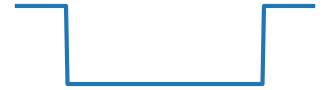
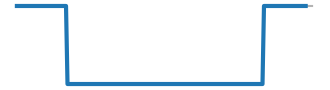
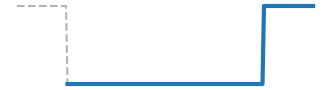
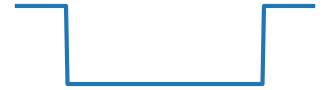
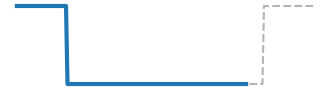

In [8]:
tv.display_transits(TOI,midTOI,ing_egr_TOI[:,0],ing_egr_TOI[:,1],TOIparams,GTC,constraints,baseline=1,visibility_cut=90)

### Display observability of transits from observatory 1 as seen by observatory 2 with `.simultaneous_observing` function

,Local Evening Date @ GTC,Moon,Start-Mid-End,Alt (S/M/E),TOI-1268 b Transit,% Transit,% Baseline,Local Evening Date @ Dharma,Transit @ Dharma,Moon @ Dharma,% Transit @ Dharma,% Baseline @ Dharma
4,GTCFri. 2026-04-03(UTC),96% @ 81°,00:0502:0504:05,53°56°49°,,100%,100%,DharmaFri. 2026-04-03(US/Mountain),,96% @ 81°,36%,50%
10,GTCFri. 2026-05-22(UTC),45% @ 61°,22:4800:4802:48,56°49°36°,,100%,93%,DharmaThu. 2026-05-21(US/Mountain),,45% @ 60°,0%,24%
42,GTCSun. 2027-02-07(UTC),2% @ 118°,23:5501:5503:55,30°44°54°,,100%,50%,DharmaSun. 2027-02-07(US/Mountain),,2% @ 118°,0%,0%
48,GTCSun. 2027-03-28(UTC),60% @ 104°,22:3800:3802:38,43°54°56°,,100%,100%,DharmaSat. 2027-03-27(US/Mountain),,60% @ 104°,2%,50%
49,GTCMon. 2027-04-05(UTC),1% @ 111°,02:2504:2506:25,55°46°32°,,92%,50%,DharmaMon. 2027-04-05(US/Mountain),,1% @ 111°,94%,50%

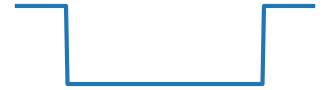
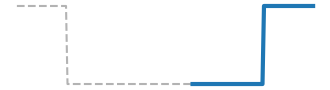
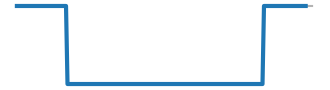
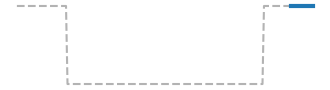
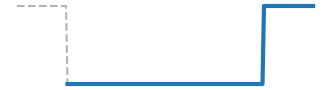
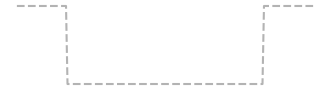
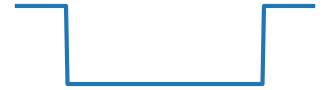
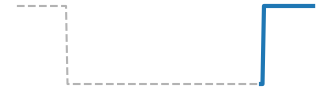
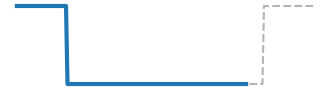
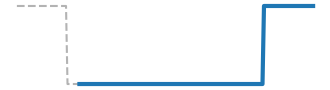

In [11]:
tv.simultaneous_observing(TOI,midTOI,ing_egr_TOI[:,0],ing_egr_TOI[:,1],TOIparams,GTC,lemon,constraints,baseline=1,visibility_cut=90)